In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt
import seaborn as sns
import torch

!pip install sentence-transformers

from sentence_transformers import SentenceTransformer

In [2]:
def get_embeddings(text, model):
    text = [str(t) for t in text]
    #encode text in batches 
    corpus_embeddings = model.encode(text, batch_size=1024, show_progress_bar=False, convert_to_tensor=True)
    assert len(corpus_embeddings) == len(text)
    return corpus_embeddings


def analyse_dictionaires(dataset):
    
    model = SentenceTransformer(datasets[dataset])
    model.to(device)


    #Get mean embeddings for lexicon categories
    evidence_embeddings_mean = torch.mean(get_embeddings(evidence_keywords, model), dim=0).to(device)
    intuition_embeddings_mean = torch.mean(get_embeddings(intuition_keywords, model), dim=0).to(device)
    
    # Get mean embeddings for lexicon categories
    evidence_embeddings = get_embeddings(evidence_keywords, model)
    intuition_embeddings = get_embeddings(intuition_keywords, model)


    # Compute cosine similarity between the mean embeddings
    cosine_similarity = F.cosine_similarity(evidence_embeddings_mean, intuition_embeddings_mean, dim=0)
    print(f"Cosine similarity between mean embeddings: {cosine_similarity.item():.4f}")


    # Normalize embeddings
    evidence_embeddings_norm = F.normalize(evidence_embeddings, p=2, dim=1)
    intuition_embeddings_norm = F.normalize(intuition_embeddings, p=2, dim=1)
    
    # Compute cosine similarity matrix
    similarity_matrix = torch.mm(evidence_embeddings_norm, intuition_embeddings_norm.T).cpu().numpy()

    # Define a diverging colormap where neutral (0) is white
    cmap = sns.diverging_palette(240, 10, as_cmap=True)  # 240 (blue) to 10 (red), centered at white
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(
        similarity_matrix,
        xticklabels=intuition_keywords,
        yticklabels=evidence_keywords,
        cmap=cmap,
        center=0,  # 0 is white
        annot=False
    )
    plt.xlabel("Intuition Keywords")
    plt.ylabel("Evidence Keywords")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.savefig(f"dictionary_correlation_{dataset}.png")
    plt.show()

    


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
evidence_keywords = pd.read_csv("/kaggle/input/dictionary2/PRODEMINFO_German_keywords.csv")['evidence'].dropna().tolist()
intuition_keywords = pd.read_csv("/kaggle/input/dictionary2/PRODEMINFO_German_keywords.csv")['intuition'].dropna().tolist()

In [4]:
datasets = {}
datasets["speeches"] = "/kaggle/input/sbert-model-new/model"
datasets["youtube"] =  "/kaggle/input/sbert-model-yt/yt_model"
datasets["twitter"] = "/kaggle/input/sbert-twitter/twitter_model"

Analysis for speeches
Cosine similarity between mean embeddings: 0.3241


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


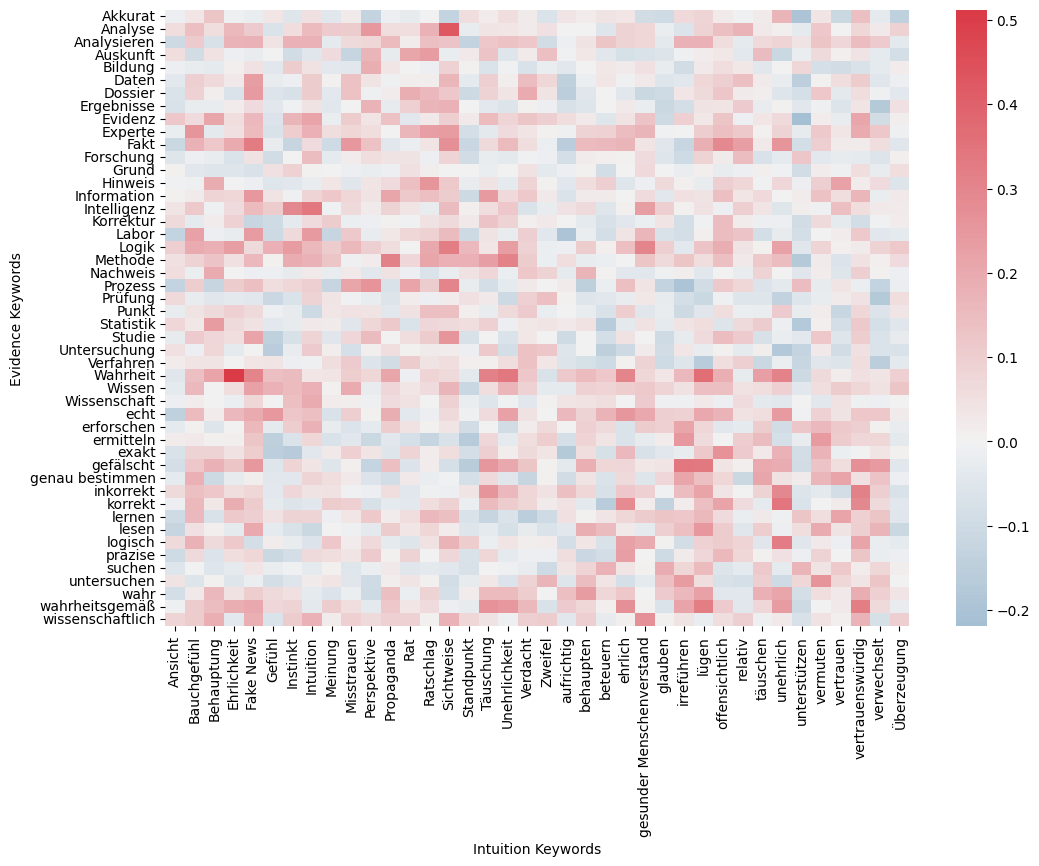

Analysis for youtube
Cosine similarity between mean embeddings: 0.4442


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


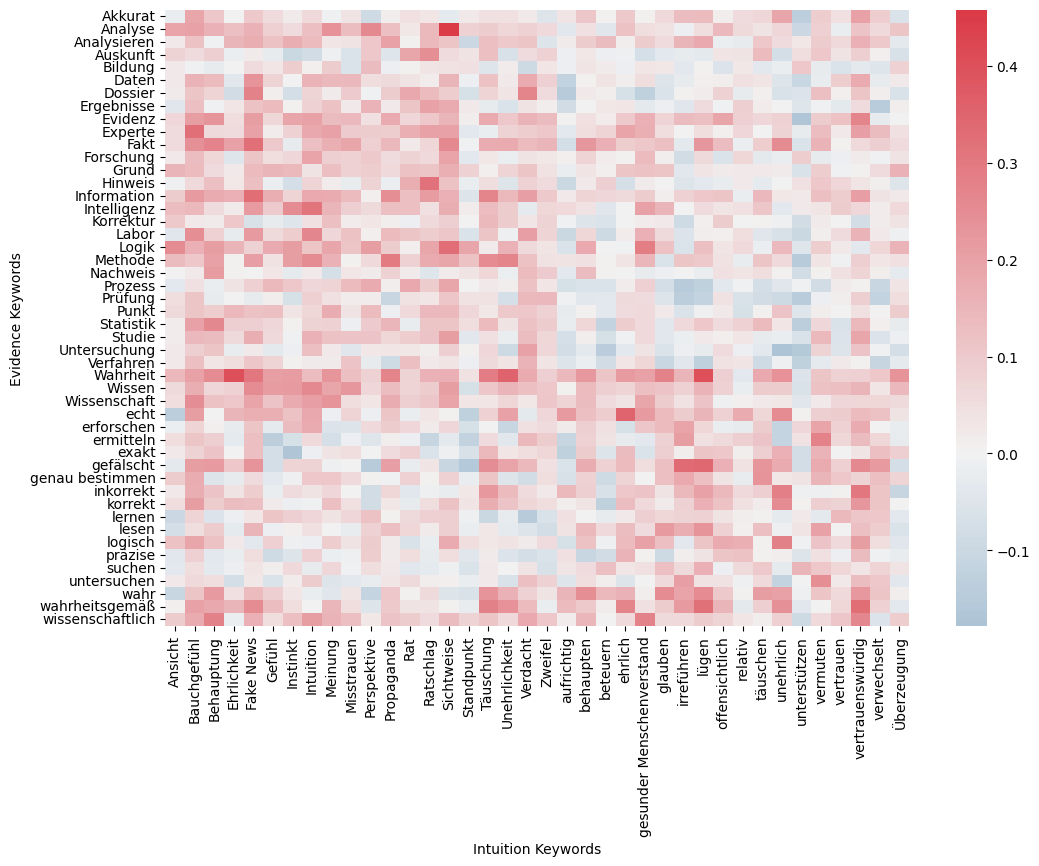

Analysis for twitter
Cosine similarity between mean embeddings: 0.4443


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


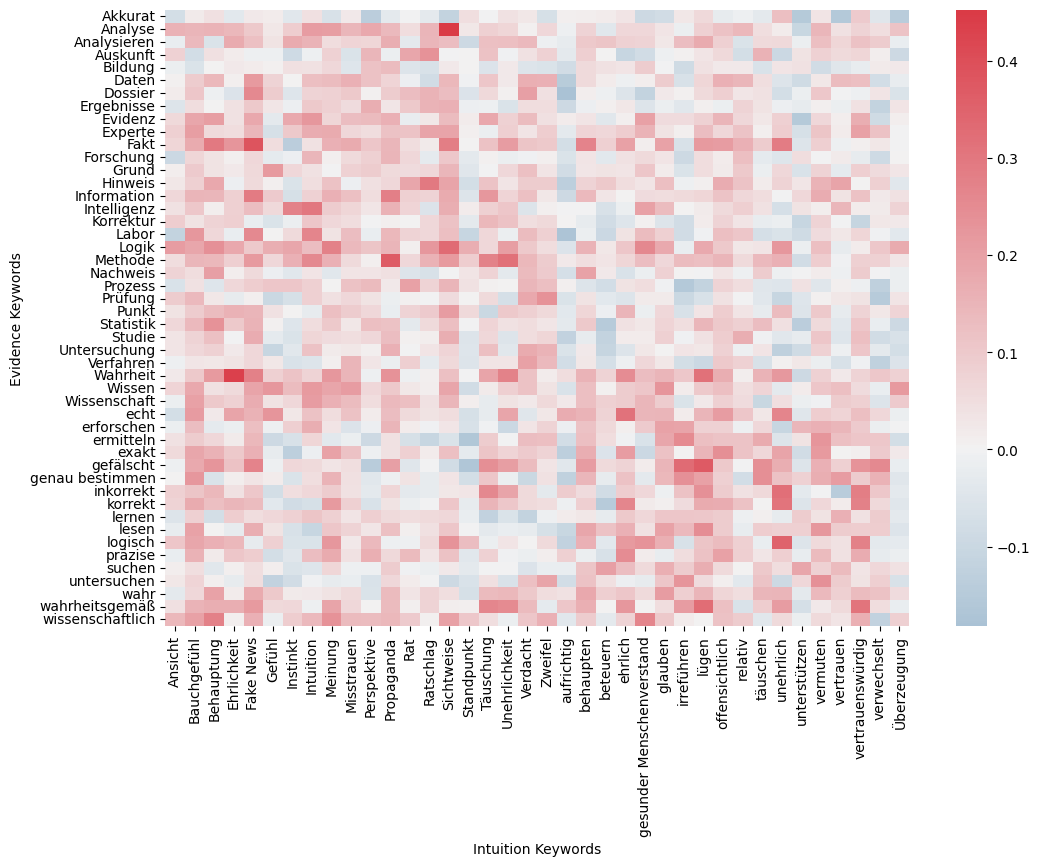

In [5]:
for key in datasets.keys():
    print(f"Analysis for {key}")
    analyse_dictionaires(key)